<h1 align="center">
  Hypothesis Testing
</h1>


In [39]:
import pandas as pd
import numpy as np
from scipy import stats
data = pd.read_csv("../Day_13/preprocessed_earthquake_data.csv")
data=data[data['Mw'].notnull()]
data.head()


,latitude,longitude,depth,mag,magType,rms,type,status,Year,Month,Day,Hour,Minute,Second,DayOfWeek,Mw,damage_potential
0,41.758,23.249,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,4,10,26,0,0,7.02,10.0
1,41.802,23.108,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,4,10,2,34,0,6.84,10.0
2,52.763,160.277,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,6,25,21,0,38,5,7.70,10.0
3,51.424,161.638,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,6,25,14,45,39,5,7.50,10.0
4,30.684,100.608,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,8,30,11,43,20,1,7.09,10.0


### Task 1: Magnitude Difference by Earthquake Type
 
<b> Research Question: </b> Do different earthquake types (e.g., earthquake, explosion, quarry blast) have
 signicantly different magnitudes?

 <b> Hypotheses: </b>

 <b> H0:</b> The mean magnitude across all earthquake types is equal.

 <b> H1:</b> At least one earthquake type has a signicantly different mean magnitude.
 
 <b> Statistical Test: </b> One-Way ANOVA or Kruskal-Wallis H-test (if normality violated)


In [40]:
# --- 1️ Group data by 'type' ---
grouped = data.groupby('type')['Mw']

# --- 2️ Calculate mean and variance ---
summary_stats = grouped.agg(['mean', 'var', 'count']).reset_index()
print("Descriptive Statistics by Earthquake Type:")
print(summary_stats)

# --- 3️ Check normality (Shapiro-Wilk) safely ---
normality_results = {}
for t, vals in grouped:
    vals = vals.dropna()
    if len(vals) >= 3:
        sample = vals.sample(n=min(len(vals), 5000), random_state=42)
        _, p = stats.shapiro(sample)
        normality_results[t] = p

normal_groups = [p > 0.05 for p in normality_results.values()]
print("\nNormality p-values (Shapiro-Wilk):", normality_results)

# --- 4️ Decide which test to use ---
if all(normal_groups):
    F_stat, p_val = stats.f_oneway(*[vals for _, vals in grouped])
    test_used = "One-Way ANOVA"
else:
    F_stat, p_val = stats.kruskal(*[vals for _, vals in grouped])
    test_used = "Kruskal-Wallis H-test"

print(f"\nStatistical Test Used: {test_used}")
print(f"Test Statistic: {F_stat:.4f}")
print(f"p-value: {p_val:.4f}")


Descriptive Statistics by Earthquake Type:
                type      mean       var   count
0         earthquake  6.054709  0.424036  109224
1          explosion  6.945300  0.055314      10
2          landslide  5.400000  0.000000       2
3      mine collapse  5.216000       NaN       1
4  nuclear explosion  6.844410  0.165884     424
5         rock burst  6.818000       NaN       1
6  volcanic eruption  5.279245  0.007061      53

Normality p-values (Shapiro-Wilk): {'earthquake': np.float64(5.718697240735353e-49), 'explosion': np.float64(0.12944181437633284), 'nuclear explosion': np.float64(1.5339618049786164e-23), 'volcanic eruption': np.float64(8.417232397385927e-09)}

Statistical Test Used: Kruskal-Wallis H-test
Test Statistic: 821.6490
p-value: 0.0000


<b>Result:</b> Using the Kruskal–Wallis H-test (chosen because normality was violated for some groups), we obtain H ≈ 821.65 with p < 0.001, so we <b> reject H₀</b> and accept H₁ — i.e., the mean magnitude is not equal across all earthquake types, at least one type has a significantly different mean magnitude.

### Task 2: Damage Potential by Magnitude Categories
 
<b> Research Question: </b> Is there a signi cant difference in damage_potential between high-magnitude and
 low-magnitude earthquakes?

 <b> Hypotheses: </b>

 <b> H0:</b>  The mean damage_potential of high-magnitude earthquakes (Mw ≥ median) equals that of
 low-magnitude earthquakes (Mw < median).

 <b> H1:</b> The means differ signicantly between magnitude categories.
 
 <b> Statistical Test: </b>  Independent samples t-test or Mann-Whitney U test (non-parametric alternative)


In [41]:
# --- 1️ Partition data based on median Mw ---
median_Mw = data['Mw'].median()
low_mag = data[data['Mw'] < median_Mw]['damage_potential']
high_mag = data[data['Mw'] >= median_Mw]['damage_potential']

# --- 2️ Check normality (Shapiro-Wilk) ---
p_low = stats.shapiro(low_mag.sample(min(5000, len(low_mag))))[1] if len(low_mag) > 3 else 1
p_high = stats.shapiro(high_mag.sample(min(5000, len(high_mag))))[1] if len(high_mag) > 3 else 1

# --- 3️ Decide test type based on normality ---
if p_low > 0.05 and p_high > 0.05:
    # Use Independent t-test
    stat, p_val = stats.ttest_ind(high_mag, low_mag, equal_var=False)
    test_used = "Independent Samples t-test"
else:
    # Use Mann–Whitney U test
    stat, p_val = stats.mannwhitneyu(high_mag, low_mag, alternative='two-sided')
    test_used = "Mann–Whitney U test"

# --- 4️ Confidence intervals for mean difference (approx) ---
mean_diff = high_mag.mean() - low_mag.mean()
se_diff = np.sqrt(high_mag.var()/len(high_mag) + low_mag.var()/len(low_mag))
ci_low, ci_high = mean_diff - 1.96*se_diff, mean_diff + 1.96*se_diff

# --- 5️ Print results ---
print(f"Statistical Test Used: {test_used}")
print(f"Test Statistic: {stat:.4f}")
print(f"p-value: {p_val:.4f}")
print(f"Mean Damage (High Mw): {high_mag.mean():.4f}")
print(f"Mean Damage (Low Mw): {low_mag.mean():.4f}")
print(f"95% Confidence Interval for Mean Difference: ({ci_low:.4f}, {ci_high:.4f})")


Statistical Test Used: Mann–Whitney U test
Test Statistic: 1662554649.0000
p-value: 0.0000
Mean Damage (High Mw): 9.6755
Mean Damage (Low Mw): 9.3468
95% Confidence Interval for Mean Difference: (0.3122, 0.3452)


<b>Result:</b> The Mann–Whitney U test revealed a statistically significant difference (p < 0.001) between high- and low-magnitude earthquakes in terms of damage potential. High-magnitude earthquakes ( mean = 9.68 ) tend to cause greater damage than low-magnitude ones (mean = 9.35). Thus,    <b>H₀ is rejected</b>, confirming that magnitude level significantly influences earthquake damage.

### Task 3: Depth Impact on Magnitude
 
<b> Research Question: </b>  Does earthquake depth signicantly correlate with magnitude?

 <b> Hypotheses: </b>

 <b> H0:</b>  There is no signicant correlation between depth and magnitude (ρ = 0).

 <b> H1:</b>  There is a signicant correlation between depth and magnitude (ρ ≠ 0).
 
 <b> Statistical Test: </b>  Pearson Correlation Test or Spearman Rank Correlation (for non-linear relationships)


In [42]:
corr, p_value = stats.pearsonr(data['depth'], data['Mw'])

n = len(data)
z = np.arctanh(corr)
se = 1 / np.sqrt(n - 3)
z_conf = 1.96 * se
ci_lower, ci_upper = np.tanh([z - z_conf, z + z_conf])

print(f"Pearson Correlation (ρ): {corr:.3f}")
print(f"P-value: {p_value:.4f}")
print(f"95% Confidence Interval: ({ci_lower:.3f}, {ci_upper:.3f})")



Pearson Correlation (ρ): 0.069
P-value: 0.0000
95% Confidence Interval: (0.064, 0.075)


<b>Result: </b>The Pearson correlation coefficient is ρ = 0.069 with a p-value < 0.001 and a 95% confidence interval of (0.064, 0.075).
Since the p-value < 0.05, <b> H₀ is rejected </b> and H₁ is accepted, indicating a statistically significant but very weak positive correlation between earthquake depth and magnitude.

### Task 4: Temporal Seasonality in Earthquake Frequency
 
<b> Research Question: </b>   Does earthquake frequency differ signicantly across months (seasonal effect)?

 <b> Hypotheses: </b>

 <b> H0:</b>  Earthquake frequency is uniform across all months (no seasonal effect).

 <b> H1:</b>   Earthquake frequency varies signicantly by month.
 
 <b> Statistical Test: </b>   Chi-Square Goodness-of-Fit Test or One-Way ANOVA on monthly counts


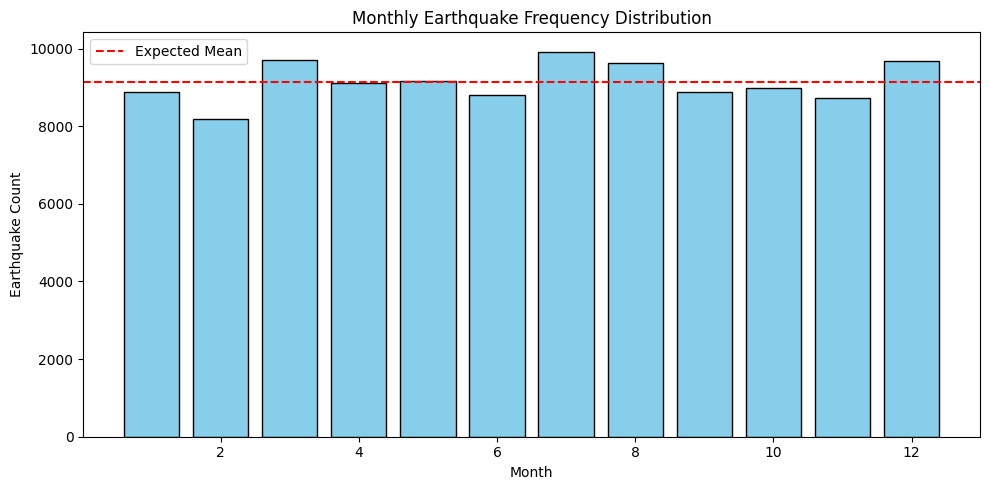

Chi-Square Statistic: 310.9497
Degrees of Freedom: 11
p-value: 0.0000


In [43]:
import matplotlib.pyplot as plt

# --- 1️ Count earthquakes per month ---
monthly_counts = data['Month'].value_counts().sort_index()

# --- 2️ Expected frequency (uniform distribution) ---
expected = np.ones_like(monthly_counts) * (monthly_counts.sum() / 12)

# --- 3️ Chi-Square Goodness-of-Fit Test ---
chi2_stat, p_val = stats.chisquare(monthly_counts, expected)

# --- 4️ Visualization ---
plt.figure(figsize=(10, 5))
plt.bar(monthly_counts.index, monthly_counts.values, color='skyblue', edgecolor='black')
plt.axhline(y=np.mean(monthly_counts), color='red', linestyle='--', label='Expected Mean')
plt.title("Monthly Earthquake Frequency Distribution")
plt.xlabel("Month")
plt.ylabel("Earthquake Count")
plt.legend()
plt.tight_layout()
plt.show()

# --- 5️ Print results ---
print(f"Chi-Square Statistic: {chi2_stat:.4f}")
print(f"Degrees of Freedom: {len(monthly_counts)-1}")
print(f"p-value: {p_val:.4f}")


<b>Result:</b> The Chi-Square Goodness-of-Fit test produced a statistic of 310.95 with 11 degrees of freedom and a p-value < 0.0001. Since the p-value is less than 0.05, we <b> reject the null hypothesis (H₀) </b> and accept H₁, indicating that earthquake frequency varies significantly across months, showing a clear seasonal pattern in seismic activity.

### Task 5: RMS Variability by Magnitude Type
 
<b> Research Question: </b>   Do different magnitude type classications (magType) show signicantly different
 RMS (residual mean square) variability?

 <b> Hypotheses: </b>

 <b> H0:</b>   The mean RMS across all magType categories is equal.

 <b> H1:</b>    At least one magType category has a signicantly different mean RMS.
 
 <b> Statistical Test: </b>    One-Way ANOVA or Levene's Test (for homogeneity of variances).


In [44]:
# Remove missing values
data = data[data['rms'].notnull() & data['magType'].notnull()]

# --- 1️ Group data by 'magType' ---
grouped = data.groupby('magType')['rms']

# --- 2️ Descriptive Statistics ---
summary_stats = grouped.agg(['mean', 'var', 'count']).reset_index()
print("Descriptive Statistics by magType:")
print(summary_stats)

# --- 3️ Levene’s Test for Equality of Variances ---
levene_stat, levene_p = stats.levene(*[vals for _, vals in grouped])
print(f"\nLevene’s Test: Statistic = {levene_stat:.4f}, p-value = {levene_p:.4f}")

# --- 4️ One-Way ANOVA ---
anova_stat, anova_p = stats.f_oneway(*[vals for _, vals in grouped])
print(f"\nANOVA Test: F = {anova_stat:.4f}, p-value = {anova_p:.4f}")

# --- 5️ Effect Size (η²) ---
k = len(grouped)
N = len(data)
eta_squared = (anova_stat * (k - 1)) / (anova_stat * (k - 1) + (N - k))
print(f"Effect Size (η²): {eta_squared:.4f}")


Descriptive Statistics by magType:
   magType      mean        var  count
0       Mb -0.101111        NaN      1
1       Ml -1.722199        NaN      1
2       mb -0.034724   0.410024  45084
3       ml -1.133615  41.187533    485
4       ms  0.258333   0.235183   3157
5       mw  0.172614   0.197611  24335
6      mwb  0.042883   0.300312   3082
7      mwc  0.126692   0.290646  17458
8      mwp -1.972956   0.242597      9
9      mwr -0.129691   0.506094    451
10     mww -0.334510   0.526207  15652

Levene’s Test: Statistic = 497.6172, p-value = 0.0000

ANOVA Test: F = 693.9171, p-value = 0.0000
Effect Size (η²): 0.0595


<b> Result: </b> Levene’s test (p = 0.0000) indicates unequal variances across magnitude types. The ANOVA result (F = 693.9171, p = 0.0000, η² = 0.0595) shows a statistically significant difference in RMS among different magType categories. Hence, <b>H₀ is rejected </b>, supporting H₁ that RMS varies significantly with magnitude type.